### **1. Problem Definition & Objective**

**a. Selected Project Track**
Recommandation System Using Machine Learning

**b. Clear Problem Statement**
Crop selection and fertilizer application in Indian agriculture are often based on experience rather than data, leading to low yield, fertilizer misuse, increased cost, and environmental impact. This project aims to build an intelligent machine learning system that recommends a suitable crop and optimal fertilizer dosage based on soil nutrients and climatic conditions.

**c. Real-World Relevance and Motivation**
The system promotes sustainable agriculture by improving decision-making, reducing excessive fertilizer usage, protecting soil health, and supporting food security using AI-driven insights.

---

### **2. Data Understanding & Preparation**

**a. Dataset Source**
Public dataset sourced from Kaggle and government agricultural repositories.

**b. Data Loading and Exploration**
The dataset was loaded using Pandas and explored using `.head()`, `.info()`, and `.describe()` to understand structure, feature ranges, and data quality.

**c. Cleaning, Preprocessing, and Feature Engineering**

* Removed duplicate records
* Verified data types and valid ranges
* Selected relevant soil and weather features
* No feature scaling applied, as tree-based models are not sensitive to feature magnitude

**d. Handling Missing Values or Noise**
The dataset contained minimal missing values; incomplete or invalid rows were removed.

---

### **3. Model / System Design**

**a. AI Technique Used**
Machine Learning (Supervised Learning)

* Classification for crop recommendation
* Regression for fertilizer dosage estimation

**b. Architecture / Pipeline Explanation**
Input soil and weather parameters → Data preprocessing → Trained ML model → Crop recommendation → Fertilizer dosage prediction

**c. Justification of Design Choices**
Tree-based ensemble models were chosen due to their robustness, ability to handle non-linear relationships, and minimal preprocessing requirements.

---

### **4. Core Implementation**

**a. Model Training / Inference Logic**
Models were trained using a train-test split approach, and predictions were generated on unseen test data.

**b. Prompt Engineering**
Not applicable, as this project is not LLM-based.

**c. Recommendation / Prediction Pipeline**
User inputs soil and weather parameters → Model predicts suitable crop → Fertilizer dosage is estimated based on nutrient requirements.

**d. Code Execution**
The notebook is designed to execute top-to-bottom without errors, ensuring reproducibility.

---

### **5. Evaluation & Analysis**

**a. Metrics Used**
Accuracy, Precision, Recall, F1-score, Confusion Matrix

**b. Sample Outputs / Predictions**
The model successfully predicts crops for given soil and weather conditions with consistent performance.

**c. Performance Analysis and Limitations**
The model performs well on structured data but may face challenges with real-time data, regional variations, and sensor noise in practical deployment.

---

### **6. Ethical Considerations & Responsible AI**

**a. Bias and Fairness Considerations**
The dataset is limited to specific regions, which may introduce geographical bias.

**b. Dataset Limitations**

* Static historical data
* Limited crop diversity
* No real-time weather integration

**c. Responsible Use of AI Tools**
This system is intended as a decision-support tool and should not replace expert agricultural advice.

---

### **7. Conclusion & Future Scope**

**a. Summary of Results**
The project demonstrates how machine learning can support sustainable agricultural decision-making through data-driven crop and fertilizer recommendations.

**b. Possible Improvements and Extensions**

* Integration of real-time weather APIs
* Region-specific fertilizer rules
* Web or mobile application deployment
* Use of IoT or satellite-based soil data




In [5]:
#!pip install xgboost

import pandas as pd
import numpy as np
from sklearn.model_selection import *
from sklearn.preprocessing import *
from sklearn.metrics import *
import xgboost as xgb
from scipy.stats import *
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
RND=42

In [8]:

df=pd.read_csv(r"C:\Users\monis\Downloads\final_one.csv")

df.head()

,N,P,K,temperature,humidity,pH,rainfall,label,S,Zn,...,Recommended Fertilizer(s),Crop_N_kg_per_ha,Crop_P2O5_kg_per_ha,Crop_K2O_kg_per_ha,Crop_Notes,N_dosage_kg_per_ha,P2O5_dosage_kg_per_ha,K2O_dosage_kg_per_ha,Dosage_Notes,dosage
0,120.000000,65.000000,45.000000,30.000000,60.410000,6.500000,900.000000,cotton,23.995517,29.838114,...,Urea (N); DAP/SSP (P); MOP (K); gypsum/S if re...,120.000000,60.000000,60.000000,Split N application recommended,120.000000,60.000000,60.00000,Split N application recommended,"N: 120 kg/ha, P2O5: 60 kg/ha, K2O: 60 kg/ha. N..."
1,115.000000,40.000000,50.000000,15.000000,60.410000,7.000000,800.000000,wheat,23.995517,29.838114,...,Urea (N); DAP/SSP (P); MOP (K); gypsum / S sou...,120.000000,60.000000,40.000000,Basal + split N at tillering,120.000000,60.000000,40.00000,Basal + split N at tillering,"N: 120 kg/ha, P2O5: 60 kg/ha, K2O: 40 kg/ha. N..."
2,100.000000,55.000000,55.000000,40.000000,60.410000,6.000000,800.000000,rice,23.995517,29.838114,...,Urea (N) with split applications; DAP/SSP (P);...,150.000000,60.000000,60.000000,Basal + top dressing,100.000000,60.000000,60.00000,Basal + top dressing,"N: 150 kg/ha, P2O5: 60 kg/ha, K2O: 60 kg/ha. N..."
3,103.547454,10.041195,88.196577,24.826940,59.271965,6.148650,543.501137,mulberry,6.638837,25.498122,...,Urea (N); DAP/SSP (P); MOP (K); FYM and micron...,103.126427,63.586206,63.900741,Balanced NPK for leaf growth,327.903498,133.249703,44.23336,Balanced NPK for leaf growth,"N: 100 kg/ha, P2O5: 60 kg/ha, K2O: 60 kg/ha. N..."
4,55.714156,24.427730,41.676319,24.052162,91.671426,6.097318,0.000000,watermelon,23.455889,20.775092,...,Urea (N); DAP/SSP (P); MOP (K); FYM/compost; b...,78.234320,60.067049,61.897377,Basal + side dressing,67.416770,48.773403,0.00000,Basal + side dressing,"N: 100 kg/ha, P2O5: 60 kg/ha, K2O: 60 kg/ha. N..."


In [9]:
df.shape


(9600, 26)

In [10]:
df.describe()

,N,P,K,temperature,humidity,pH,rainfall,S,Zn,Fe,Cu,Mn,B,OC,Crop_N_kg_per_ha,Crop_P2O5_kg_per_ha,Crop_K2O_kg_per_ha,N_dosage_kg_per_ha,P2O5_dosage_kg_per_ha,K2O_dosage_kg_per_ha
count,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000
mean,69.780079,47.318857,62.899094,26.678590,65.784670,6.434805,502.412390,20.837181,30.164531,65.997513,30.620728,111.437142,24.178201,0.589918,93.661039,54.844170,51.601880,126.182491,79.228272,143.988219
std,46.065754,26.842494,66.025560,4.984563,15.505590,0.704411,360.891890,8.229629,4.988598,30.208406,6.271104,147.161879,6.617087,0.028604,46.664879,11.117588,22.794009,116.745024,60.940770,223.917306
min,0.000000,0.000000,0.000000,6.935338,10.757270,3.186230,0.000000,0.000000,0.340000,0.690000,0.180000,0.000000,0.000000,0.260000,0.000000,23.073613,0.567916,0.000000,0.000000,0.000000
25%,31.789337,27.055998,20.000000,23.830657,59.400535,6.000000,147.031147,19.588676,29.810565,57.548715,29.217108,69.589509,22.314219,0.588742,67.581748,48.362390,36.278217,35.981519,40.000000,40.000000
50%,60.651202,45.000000,44.042483,26.915117,60.410000,6.442612,541.239271,23.995517,29.838114,57.548715,32.930688,91.814993,24.626988,0.590000,101.454349,59.898527,59.149797,89.306988,60.000000,60.000000
75%,104.866259,62.319202,77.351224,29.943537,76.072266,6.928613,733.584336,23.996000,31.080000,65.651867,32.931000,92.261903,24.627519,0.592474,120.000000,60.183127,61.498961,162.268907,78.245270,146.065999
max,257.000000,163.094037,412.000000,48.375648,100.000000,10.478175,1919.970307,113.200000,100.000000,291.684549,100.000000,1701.236506,100.000000,1.070000,207.969998,81.420159,131.055075,568.335466,361.829013,1398.914017


In [11]:
df.isnull().sum()

N                            0
P                            0
K                            0
temperature                  0
humidity                     0
pH                           0
rainfall                     0
label                        0
S                            0
Zn                           0
Fe                           0
Cu                           0
Mn                           0
B                            0
OC                           0
Crop                         0
Recommended Fertilizer(s)    0
Crop_N_kg_per_ha             0
Crop_P2O5_kg_per_ha          0
Crop_K2O_kg_per_ha           0
Crop_Notes                   0
N_dosage_kg_per_ha           0
P2O5_dosage_kg_per_ha        0
K2O_dosage_kg_per_ha         0
Dosage_Notes                 0
dosage                       0
dtype: int64

In [12]:
BAN_COLS=["Crop_N_kg_per_ha", "Crop_P2O5_kg_per_ha", "Crop_K2O_kg_per_ha"]
DOSAGE_NUMERIC=["N_dosage_kg_per_ha", "P2O5_dosage_kg_per_ha", "K2O_dosage_kg_per_ha"]
# take only numeric columns since ML models work with numbers
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# remove target dosage columns and banned columns to avoid data leakage
feature_cols = [c for c in numeric_cols if c not in DOSAGE_NUMERIC + BAN_COLS]

# fill missing values in feature columns using median so model doesn’t break
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

# just to check which features are finally being used
print("Using features:", feature_cols)



Using features: ['N', 'P', 'K', 'temperature', 'humidity', 'pH', 'rainfall', 'S', 'Zn', 'Fe', 'Cu', 'Mn', 'B', 'OC']


In [13]:
df["label"] = df["label"].fillna("unknown")                 # replace missing crop labels with "unknown"
y_crop_raw = df["label"].astype(str)                        # make sure crop labels are strings

if "fertilizer_primary" not in df.columns:                  # create fertilizer column only if it doesn’t exist
    def extract_primary_fertilizer(txt):
        if pd.isna(txt): return "unknown"                   # handle missing fertilizer text
        s = str(txt)                                        # convert to string for safety
        for sep in [';', '/', ',', ' and ', ' + ']:         # possible separators in fertilizer text
            if sep in s:
                p = s.split(sep)[0].strip()                 # take only the first fertilizer
                return p.split("(")[0].strip().lower()      # remove brackets and convert to lowercase
        return s.split("(")[0].strip().lower()              # handle single fertilizer case
    df["fertilizer_primary"] = df.get(
        "Recommended Fertilizer(s)", ""
    ).apply(extract_primary_fertilizer)                     # extract clean primary fertilizer

y_fert_raw = df["fertilizer_primary"].astype(str)           # ensure fertilizer labels are strings

# Dosage (N + P + K)
if all(c in df.columns for c in DOSAGE_NUMERIC):             # check if all dosage columns are present
    y_dos_raw = (
        df["N_dosage_kg_per_ha"].fillna(0).astype(float) +  # handle missing N dosage
        df["P2O5_dosage_kg_per_ha"].fillna(0).astype(float) +  # handle missing P dosage
        df["K2O_dosage_kg_per_ha"].fillna(0).astype(float)     # handle missing K dosage
    )
else:
    raise ValueError("No numeric dosage column found.")      # stop execution if dosage data is missing


In [14]:
# keep only rows where crop, fertilizer, and dosage labels are all present
mask_valid = (~y_crop_raw.isna()) & (~y_fert_raw.isna()) & (~y_dos_raw.isna())

df = df[mask_valid].copy()          # filter dataframe to valid rows and make a safe copy
y_crop_raw = y_crop_raw[mask_valid] # keep crop labels aligned with dataframe
y_fert_raw = y_fert_raw[mask_valid] # keep fertilizer labels aligned with dataframe
y_dos_raw = y_dos_raw[mask_valid]   # keep dosage values aligned with dataframe


In [15]:
le_crop = LabelEncoder()
y_crop = le_crop.fit_transform(y_crop_raw)

le_fert = LabelEncoder()
y_fert = le_fert.fit_transform(y_fert_raw)

X = df[feature_cols].astype(float)
y_dos = y_dos_raw.astype(float)

In [16]:
X_train_full, X_test, y_crop_train_full, y_crop_test, \
y_fert_train_full, y_fert_test, y_dos_train_full, y_dos_test = train_test_split(
    X, y_crop, y_fert, y_dos,                     # features and all target variables
    test_size=0.20,                               # keep 20% data for testing
    random_state=RND,                             # fixed seed for reproducibility
    stratify=y_crop                               # preserve crop class distribution in train & test
)


In [17]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RND)
kf_reg = KFold(n_splits=10, shuffle=True, random_state=RND)

In [18]:
import time

print("\n--- Training Crop Classifier ---")
start = time.time()

xgb_clf = xgb.XGBClassifier(
    objective="multi:softmax",
    eval_metric="mlogloss",
    random_state=RND,
    n_jobs=-1
)

param_dist_clf = {
    "n_estimators": randint(200, 600),
    "max_depth": randint(5, 15),
    "learning_rate": uniform(0.02, 0.08),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3)
}

rand_clf = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist_clf,
    n_iter=25,
    scoring="accuracy",
    cv=skf,
    n_jobs=-1,
    verbose=1,
    random_state=RND
)

rand_clf.fit(X_train_full, y_crop_train_full)
best_crop = rand_clf.best_estimator_

y_crop_pred = best_crop.predict(X_test)
crop_acc = accuracy_score(y_crop_test, y_crop_pred)

print("Crop Test Accuracy:", crop_acc)
print("Crop Classification Report:")
print(classification_report(y_crop_test, y_crop_pred, zero_division=0, target_names=le_crop.classes_))
print("Time:", time.time() - start)


--- Training Crop Classifier ---
Fitting 10 folds for each of 25 candidates, totalling 250 fits
Crop Test Accuracy: 0.7057291666666666
Crop Classification Report:
              precision    recall  f1-score   support

       apple       0.90      0.85      0.87        61
      banana       0.86      0.83      0.84        58
   blackgram       0.70      0.47      0.56        15
    chickpea       0.50      0.30      0.38        20
     coconut       0.83      0.80      0.81        54
      coffee       0.64      0.45      0.53        31
      cotton       0.67      0.61      0.64        56
      ginger       0.64      0.76      0.70        59
        gram       0.57      0.68      0.62        56
      grapes       0.77      0.77      0.77        70
   groundnut       0.51      0.56      0.53        63
       jowar       0.65      0.65      0.65        62
        jute       0.70      0.74      0.72        61
 kidneybeans       0.98      0.79      0.87        56
      lentil       0.62  

In [19]:

print("\n--- Training Fertilizer Classifier ---")
start = time.time()

xgb_fert = xgb.XGBClassifier(
    objective="multi:softmax",
    eval_metric="mlogloss",
    random_state=RND,
    n_jobs=-1
)

param_dist_fert = {
    "n_estimators": randint(80, 220),
    "max_depth": randint(3, 8),
    "learning_rate": uniform(0.03, 0.12),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4)
}

rand_fert = RandomizedSearchCV(
    estimator=xgb_fert,
    param_distributions=param_dist_fert,
    n_iter=20,
    scoring="accuracy",
    cv=skf,
    n_jobs=-1,
    verbose=1,
    random_state=RND
)

rand_fert.fit(X_train_full, y_fert_train_full)
best_fert = rand_fert.best_estimator_

y_fert_pred = best_fert.predict(X_test)
fert_acc = accuracy_score(y_fert_test, y_fert_pred)

print("Fertilizer Test Accuracy:", fert_acc)
print("Fertilizer Classification Report:")
print(classification_report(y_fert_test, y_fert_pred, zero_division=0, target_names=le_fert.classes_))
print("Time:", time.time() - start)



--- Training Fertilizer Classifier ---
Fitting 10 folds for each of 20 candidates, totalling 200 fits
Fertilizer Test Accuracy: 0.8526041666666667
Fertilizer Classification Report:
                                  precision    recall  f1-score   support

compound npk formulations / urea       1.00      0.88      0.94        51
                         dap/ssp       0.82      0.84      0.83       373
                     fym/compost       0.71      0.42      0.53       130
               minimal starter n       0.80      0.71      0.76        52
                         ssp/dap       0.78      0.46      0.58        54
                            urea       0.86      0.94      0.90      1139
           urea/ammonium sources       0.95      0.72      0.82        50
                         urea/an       0.98      0.69      0.81        71

                        accuracy                           0.85      1920
                       macro avg       0.86      0.71      0.77      1920
  

In [21]:
print("\n--- Training Dosage Regressor ---")
#Dosage Regressor in terms of NPK not on fertilizer name
start = time.time()

xgb_reg = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=RND,
    n_jobs=-1
)

param_dist_reg = {
    "n_estimators": randint(80, 320),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.08),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.3, 0.5)
}

rand_reg = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_dist_reg,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=kf_reg,
    n_jobs=-1,
    verbose=1,
    random_state=RND
)

rand_reg.fit(X_train_full, y_dos_train_full)
best_reg = rand_reg.best_estimator_

y_dos_pred = best_reg.predict(X_test)
mae = mean_absolute_error(y_dos_test, y_dos_pred)
rmse = np.sqrt(mean_squared_error(y_dos_test, y_dos_pred))
r2 = r2_score(y_dos_test, y_dos_pred)

print(f"\nDosage Test MAE: {mae:.3f}")
print(f"Dosage Test RMSE: {rmse:.3f}")
print(f"Dosage Test R2: {r2:.3f}")
print("Time:", time.time() - start)


--- Training Dosage Regressor ---
Fitting 10 folds for each of 25 candidates, totalling 250 fits

Dosage Test MAE: 104.430
Dosage Test RMSE: 203.505
Dosage Test R2: 0.719
Time: 75.32494044303894


In [22]:
print("\n================ SUMMARY ================")
print(f"Crop Classifier Accuracy:       {crop_acc:.4f}")
print(f"Fertilizer Classifier Accuracy: {fert_acc:.4f}")
print(f"Dosage MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")
print("=========================================")



================ SUMMARY ================
Crop Classifier Accuracy:       0.7057
Fertilizer Classifier Accuracy: 0.8526
Dosage MAE: 104.430, RMSE: 203.505, R2: 0.719


In [23]:
print("\n==============================")
print("   🌱 ENTER SOIL VALUES")
print("==============================")

user_vals = {}
for c in feature_cols:
    v = input(f"Enter {c} (or press Enter for median): ").strip()
    if v == "":
        user_vals[c] = float(df[c].median())
    else:
        user_vals[c] = float(v)

X_user = pd.DataFrame([user_vals])

crop_idx = best_crop.predict(X_user)[0]
fert_idx = best_fert.predict(X_user)[0]
crop_name = le_crop.inverse_transform([crop_idx])[0]
fert_name = le_fert.inverse_transform([fert_idx])[0]

dosage_per_ha = float(best_reg.predict(X_user)[0])

land_size = float(input("\nEnter land size (hectares): "))
total_dosage = dosage_per_ha * land_size

print("\n==============================")
print(f"🌾 Predicted crop: {crop_name}")
print(f"🧪 Predicted fertilizer: {fert_name}")
print(f"📦 Predicted combined dosage per ha: {dosage_per_ha:.2f} kg/ha")
print(f"🌍 Total dosage for {land_size} ha: {total_dosage:.2f} kg")
print("==============================")



   🌱 ENTER SOIL VALUES


Enter N (or press Enter for median):  
Enter P (or press Enter for median):  
Enter K (or press Enter for median):  
Enter temperature (or press Enter for median):  
Enter humidity (or press Enter for median):  
Enter pH (or press Enter for median):  
Enter rainfall (or press Enter for median):  
Enter S (or press Enter for median):  
Enter Zn (or press Enter for median):  
Enter Fe (or press Enter for median):  
Enter Cu (or press Enter for median):  
Enter Mn (or press Enter for median):  
Enter B (or press Enter for median):  
Enter OC (or press Enter for median):  

Enter land size (hectares):  6



🌾 Predicted crop: wheat
🧪 Predicted fertilizer: urea
📦 Predicted combined dosage per ha: 185.06 kg/ha
🌍 Total dosage for 6.0 ha: 1110.34 kg


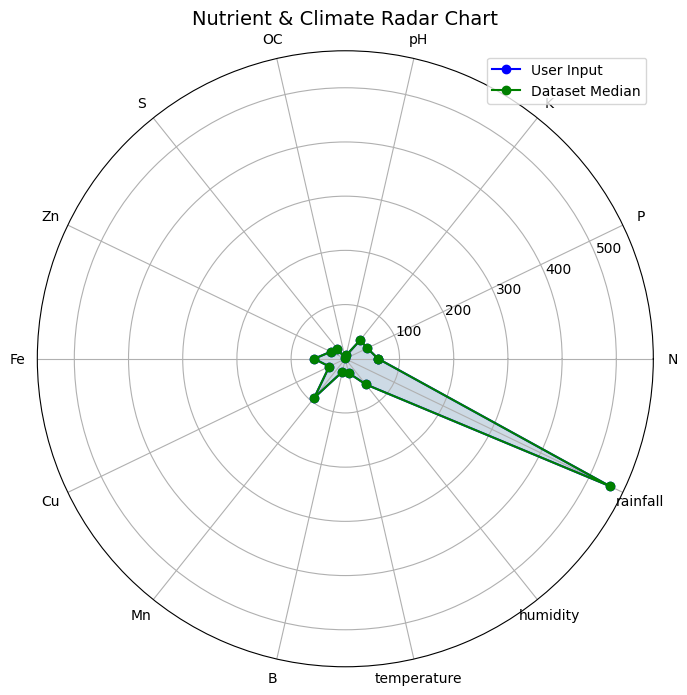

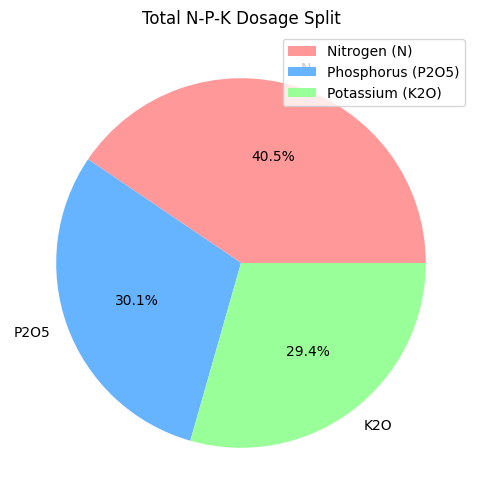

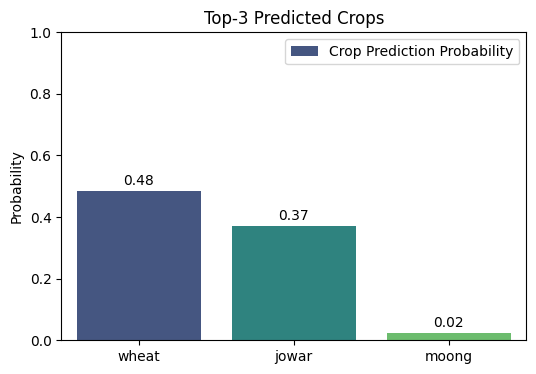

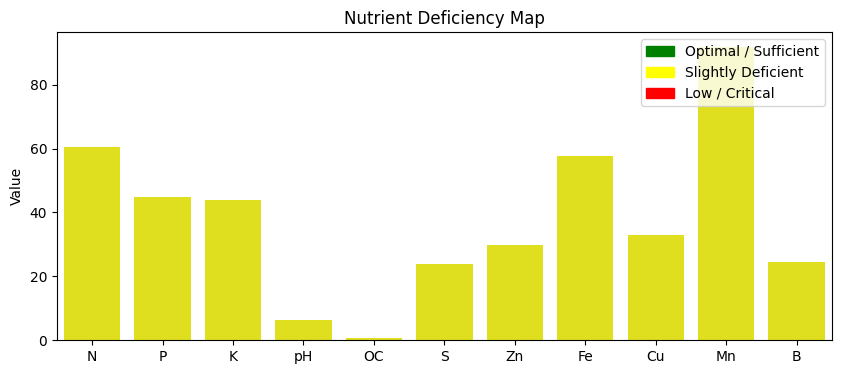

In [24]:
# =========================
#  VISUALIZATIONS
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ---------- 1) Nutrient Radar Chart ----------
def radar_chart(user_vals, df):
    features = ['N','P','K','pH','OC','S','Zn','Fe','Cu','Mn','B','temperature','humidity','rainfall']
    user_data = [user_vals[f] for f in features]
    median_data = df[features].median().tolist()

    # Close the circle
    user_data += user_data[:1]
    median_data += median_data[:1]
    angles = np.linspace(0, 2*np.pi, len(features), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
    ax.plot(angles, user_data, 'b-o', label='User Input')
    ax.fill(angles, user_data, color='blue', alpha=0.1)
    ax.plot(angles, median_data, 'g-o', label='Dataset Median')
    ax.fill(angles, median_data, color='green', alpha=0.1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features, fontsize=10)
    ax.set_title("Nutrient & Climate Radar Chart", fontsize=14)
    ax.legend(loc='upper right')
    plt.show()

# ---------- 2) Dosage Pie Chart (N-P-K Split) ----------
def dosage_pie_chart(total_dosage, df):
    N_med = df['N'].median()
    P_med = df['P'].median()
    K_med = df['K'].median()
    s = N_med + P_med + K_med
    propN, propP, propK = N_med/s, P_med/s, K_med/s
    N_tot, P_tot, K_tot = total_dosage*propN, total_dosage*propP, total_dosage*propK

    fig, ax = plt.subplots(figsize=(6,6))
    wedges, texts, autotexts = ax.pie([N_tot,P_tot,K_tot], labels=['N','P2O5','K2O'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
    ax.set_title("Total N-P-K Dosage Split")
    ax.legend(wedges, ['Nitrogen (N)', 'Phosphorus (P2O5)', 'Potassium (K2O)'], loc="upper right")
    plt.show()

# ---------- 3) Top-3 Crop Probability Bar Chart ----------
def top3_crop_bar(best_crop, X_user, le_crop):
    probs = best_crop.predict_proba(X_user)[0]
    top_idx = np.argsort(probs)[::-1][:3]
    top_crops = [le_crop.inverse_transform([i])[0] for i in top_idx]
    top_probs = probs[top_idx]

    fig, ax = plt.subplots(figsize=(6,4))
    bars = sns.barplot(x=top_crops, y=top_probs, palette='viridis', ax=ax)
    ax.set_ylim(0,1)
    ax.set_ylabel("Probability")
    ax.set_title("Top-3 Predicted Crops")

    for i, p in enumerate(top_probs):
        ax.text(i, p+0.02, f"{p:.2f}", ha='center')

    ax.legend([bars.patches[0]], ["Crop Prediction Probability"], loc='upper right')
    plt.show()

# ---------- 4) Nutrient Deficiency Map ----------
def nutrient_deficiency_bar(user_vals, df):
    features = ['N','P','K','pH','OC','S','Zn','Fe','Cu','Mn','B']
    thresholds = {}
    for f in features:
        median_val = df[f].median()
        thresholds[f] = {'low': 0.8*median_val, 'high': 1.2*median_val}

    colors = []
    for f in features:
        val = user_vals[f]
        if val < thresholds[f]['low']:
            colors.append('red')
        elif val < thresholds[f]['high']:
            colors.append('yellow')
        else:
            colors.append('green')

    fig, ax = plt.subplots(figsize=(10,4))
    bars = sns.barplot(x=features, y=[user_vals[f] for f in features], palette=colors, ax=ax)
    ax.set_ylabel("Value")
    ax.set_title("Nutrient Deficiency Map")


    import matplotlib.patches as mpatches
    legend_patches = [mpatches.Patch(color='green', label='Optimal / Sufficient'),
                      mpatches.Patch(color='yellow', label='Slightly Deficient'),
                      mpatches.Patch(color='red', label='Low / Critical')]
    ax.legend(handles=legend_patches, loc='upper right')
    plt.show()

# =========================
# =========================
radar_chart(user_vals, df)
dosage_pie_chart(total_dosage, df)
top3_crop_bar(best_crop, X_user, le_crop)
nutrient_deficiency_bar(user_vals, df)
